In [1]:
import sys, subprocess, torch
print('python:', sys.executable)
print('torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('cuda_available:', torch.cuda.is_available())
print('device_count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu0:', torch.cuda.get_device_name(0))
try:
    out = subprocess.run(['nvidia-smi', '--query-gpu=name,driver_version', '--format=csv,noheader'], capture_output=True, text=True, timeout=15)
    print('nvidia-smi:', out.stdout.strip() if out.returncode == 0 else out.stderr.strip())
except Exception as e:
    print('nvidia-smi error:', repr(e))

python: c:\Users\Santi\miniconda3\envs\GenD\python.exe
torch: 2.8.0+cu128
torch.version.cuda: 12.8
cuda_available: True
device_count: 1
gpu0: NVIDIA GeForce RTX 4060
nvidia-smi: NVIDIA GeForce RTX 4060, 581.80


In [2]:
import requests
import torch
from PIL import Image

from src.hf.modeling_gend import GenD

import torch
from PIL import Image
import os
import glob
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

c:\Users\Santi\miniconda3\envs\GenD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Inference

In [8]:
model = GenD.from_pretrained("yermandy/GenD_CLIP_L_14")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model.to(device).eval()

CUDA available: True
GPU: NVIDIA GeForce RTX 4060


In [9]:
from pathlib import Path
import pandas as pd

scale_factors = [1.30, 1.31 , 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39]

results_root = Path("imgs/evaluation/results")
predictions_dir = results_root / "predictions_by_scale"
results_root.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# Label convention in this repo: 0=real, 1=fake
LABEL_REAL = 0
LABEL_FAKE = 1

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def collect_images(root: Path):
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in image_exts])


def perform_prediction_with_processing(image_path, model, device):
    image = Image.open(image_path).convert("RGB")
    tensor = model.feature_extractor.preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=-1)

    prob_fake = probs[0, LABEL_FAKE].item()
    pred_label = LABEL_FAKE if prob_fake >= 0.5 else LABEL_REAL
    return pred_label, prob_fake


metrics_rows = []
last_eval = None

for scale_factor in scale_factors:
    real_data_path = Path(f"imgs/evaluation/real_processed_{scale_factor}")
    fake_data_path = Path(f"imgs/evaluation/fake_processed_{scale_factor}")

    samples = [(p, LABEL_REAL) for p in collect_images(real_data_path)] + [(p, LABEL_FAKE) for p in collect_images(fake_data_path)]

    if len(samples) == 0:
        print(f"Skipping scale {scale_factor}: no images found.")
        continue

    true_labels = []
    pred_labels = []
    prob_fake_scores = []
    prediction_rows = []

    print(f"Starting evaluation for scale_factor={scale_factor} on {len(samples)} images...")
    for file_path, true_label in tqdm(samples, desc=f"Evaluating scale {scale_factor}"):
        pred_label, prob_fake = perform_prediction_with_processing(file_path, model, device)
        true_labels.append(true_label)
        pred_labels.append(pred_label)
        prob_fake_scores.append(prob_fake)
        prediction_rows.append(
            {
                "image_path": str(file_path),
                "true_label": true_label,
                "pred_label": pred_label,
                "prob_fake": prob_fake,
            }
        )

    predictions_df = pd.DataFrame(prediction_rows)
    scale_tag = str(scale_factor).replace(".", "p")
    pred_out_path = predictions_dir / f"predictions_scale_{scale_tag}.csv"
    predictions_df.to_csv(pred_out_path, index=False)

    cm = confusion_matrix(true_labels, pred_labels, labels=[LABEL_REAL, LABEL_FAKE])
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tn + tp) / (tn + fp + fn + tp)

    try:
        auc_score = roc_auc_score(true_labels, prob_fake_scores)
    except ValueError:
        auc_score = None

    metrics_rows.append(
        {
            "scale_factor": scale_factor,
            "num_samples": len(samples),
            "num_real": int(sum(1 for v in true_labels if v == LABEL_REAL)),
            "num_fake": int(sum(1 for v in true_labels if v == LABEL_FAKE)),
            "accuracy": accuracy,
            "auc": auc_score,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "predictions_csv": str(pred_out_path),
        }
    )

    last_eval = (scale_factor, true_labels, pred_labels, prob_fake_scores)
    print(f"Saved predictions to {pred_out_path}")

if len(metrics_rows) == 0:
    raise ValueError("No scale factors produced samples. Please check dataset paths.")

summary_df = pd.DataFrame(metrics_rows).sort_values("scale_factor").reset_index(drop=True)
summary_path = results_root / "scale_sweep_metrics.csv"
summary_df.to_csv(summary_path, index=False)

print("\nScale sweep complete.")
print(f"Saved summary metrics to {summary_path}")

auc_table = summary_df[["scale_factor", "auc"]].copy()
print("\nAUC by scale_factor:")
for _, row in auc_table.iterrows():
    auc_value = row["auc"]
    auc_text = f"{auc_value:.6f}" if pd.notna(auc_value) else "N/A"
    print(f"scale_factor={row['scale_factor']}: AUC={auc_text}")

if summary_df["auc"].notna().any():
    best_idx = summary_df["auc"].idxmax()
    best_row = summary_df.loc[best_idx]
    print(
        f"\nBest experiment by AUC -> scale_factor={best_row['scale_factor']}, "
        f"AUC={best_row['auc']:.6f}, accuracy={best_row['accuracy']:.6f}"
    )
else:
    print("\nBest experiment by AUC -> unavailable (all AUC values are N/A)")

display(summary_df[["scale_factor", "num_samples", "accuracy", "auc"]])

# Keep these for downstream cells (use the last evaluated scale)
scale_factor, true_labels, pred_labels, prob_fake_scores = last_eval
print(f"\nUsing scale_factor={scale_factor} for downstream confusion matrix/ROC cells.")

Skipping scale 1.3: no images found.
Skipping scale 1.31: no images found.
Skipping scale 1.32: no images found.
Skipping scale 1.33: no images found.
Skipping scale 1.34: no images found.
Skipping scale 1.35: no images found.
Skipping scale 1.36: no images found.
Skipping scale 1.37: no images found.
Skipping scale 1.38: no images found.
Skipping scale 1.39: no images found.


ValueError: No scale factors produced samples. Please check dataset paths.

<Figure size 800x600 with 0 Axes>

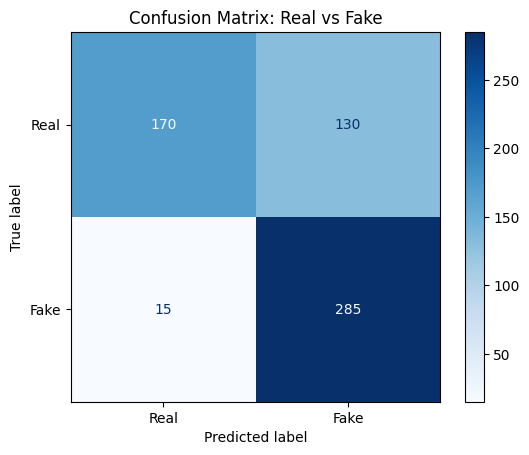

In [ ]:
# --- Confusion Matrix ---
cm = confusion_matrix(true_labels, pred_labels, labels=[LABEL_REAL, LABEL_FAKE])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix: Real vs Fake")
plt.savefig("confusion_matrix_final.png")
plt.show()


Area Under the Curve (AUC): 0.8783


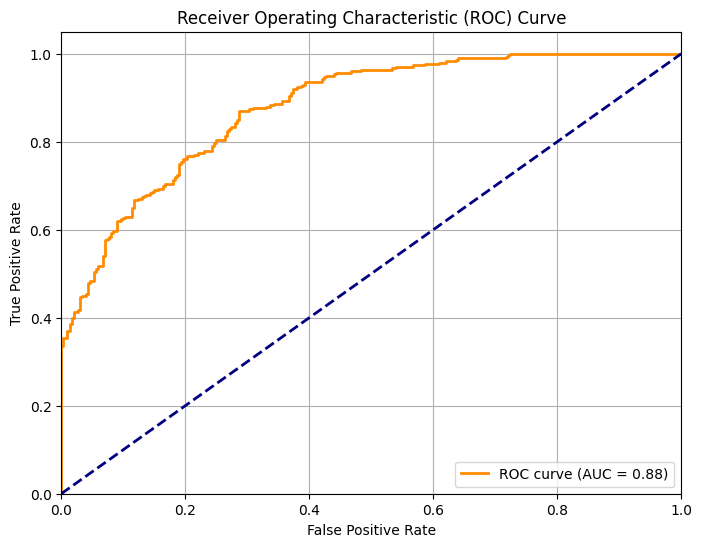

In [ ]:
# --- AUC (fake is positive class) ---
try:
    auc_score = roc_auc_score(true_labels, prob_fake_scores)
    print(f"Area Under the Curve (AUC): {auc_score:.4f}")

    fpr, tpr, _ = roc_curve(true_labels, prob_fake_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig("roc_curve_final.png")
    plt.show()
except ValueError as e:
    print(f"Could not calculate AUC: {e}")